# Visão Clássica — Parte 3: Análise de Confusões e Otimização

Continuação das Partes 1 e 2. Usando o XGBoost (melhor modelo) com as 181 características:

1. **Matrizes de confusão** (precision e recall).
2. **Maiores confusões por classe** (top 5).
3. **Agrupamento das classes irmãs** (12 → 9) e seu impacto.
4. **Otimização por remoção de características** (importância por permutação).

## 1. Setup, dataset e extração das 181 características

In [1]:
import json
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from skimage.feature import local_binary_pattern, hog
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier
from tqdm import tqdm

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "InfraredSolarModules"
DATASET_URL = "https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip"


def garantir_dataset():
    if (DATA_DIR / "module_metadata.json").exists():
        return
    zip_path = BASE_DIR / "2020-02-14_InfraredSolarModules.zip"
    if not zip_path.exists():
        print("Baixando dataset ...")
        urllib.request.urlretrieve(DATASET_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(BASE_DIR)


garantir_dataset()
df = pd.DataFrame.from_dict(json.load(open(DATA_DIR / "module_metadata.json")), orient="index")

GABOR_KERNELS = [cv2.getGaborKernel((9, 9), 2.0, th, 4.0, 0.5, 0, ktype=cv2.CV_32F)
                 for th in np.deg2rad([0, 45, 90, 135])]


def extrair_features(img):
    img = img.astype(np.uint8)
    total = img.size
    f = {}
    f["mean_int"] = float(img.mean())
    f["std_int"] = float(img.std())
    f["max_int"] = float(img.max())
    f["min_int"] = float(img.min())
    f["p90_int"] = float(np.percentile(img, 90))
    otsu_t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, hot = cv2.threshold(img, max(otsu_t, 180), 255, cv2.THRESH_BINARY)
    hot = cv2.morphologyEx(hot, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    f["hot_fraction"] = float(hot.sum() / 255) / total
    contornos, _ = cv2.findContours(hot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = [c for c in contornos if cv2.contourArea(c) >= 2]
    f["num_blobs"] = float(len(blobs))
    if blobs:
        maior = max(blobs, key=cv2.contourArea)
        area = cv2.contourArea(maior)
        x, y, w, h = cv2.boundingRect(maior)
        f["largest_area"] = float(area)
        f["largest_extent"] = float(area / (w * h)) if w * h > 0 else 0.0
        f["largest_aspect"] = float(w / h) if h > 0 else 0.0
    else:
        f["largest_area"] = f["largest_extent"] = f["largest_aspect"] = 0.0
    f["row_cov"] = float((hot.sum(axis=1) > 0).mean())
    f["col_cov"] = float((hot.sum(axis=0) > 0).mean())
    f["dark_fraction"] = float((img < (img.mean() - img.std())).mean())
    f["edge_density"] = float((cv2.Canny(img, 50, 150) > 0).mean())
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    f["grad_mean"] = float(np.sqrt(gx ** 2 + gy ** 2).mean())
    imgf = img.astype(np.float32)
    f["sym_lr"] = float(np.abs(imgf - np.fliplr(imgf)).mean())
    f["sym_tb"] = float(np.abs(imgf - np.flipud(imgf)).mean())
    hist = cv2.calcHist([img], [0], None, [8], [0, 256]).flatten()
    hist = hist / hist.sum()
    for i, hv in enumerate(hist):
        f[f"hist{i}"] = float(hv)
    f["skew_int"] = float(skew(imgf.ravel())) if img.std() > 0 else 0.0
    f["kurt_int"] = float(kurtosis(imgf.ravel())) if img.std() > 0 else 0.0
    hu = np.zeros(7)
    if blobs:
        mk = np.zeros_like(img)
        cv2.drawContours(mk, [maior], -1, 255, -1)
        huv = cv2.HuMoments(cv2.moments(mk)).flatten()
        hu = np.array([-np.sign(v) * np.log10(abs(v) + 1e-30) for v in huv])
    for i in range(7):
        f[f"hu_{i}"] = float(hu[i])
    hh, ww = img.shape
    hs, ws = hh // 3, ww // 3
    for i in range(3):
        for j in range(3):
            y0, y1 = i * hs, (hh if i == 2 else (i + 1) * hs)
            x0, x1 = j * ws, (ww if j == 2 else (j + 1) * ws)
            f[f"grid_{i}{j}"] = float(img[y0:y1, x0:x1].mean())
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    lh, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    for k, v in enumerate(lh):
        f[f"lbp_{k}"] = float(v)
    for i, kern in enumerate(GABOR_KERNELS):
        resp = cv2.filter2D(imgf, cv2.CV_32F, kern)
        f[f"gabor{i}_mean"] = float(resp.mean())
        f[f"gabor{i}_std"] = float(resp.std())
    for k, v in enumerate(hog(imgf, orientations=8, pixels_per_cell=(8, 8),
                              cells_per_block=(1, 1), feature_vector=True, channel_axis=None)):
        f[f"hog_{k}"] = float(v)
    return f


registros, y = [], []
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    img = cv2.imread(str(DATA_DIR / row["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    registros.append(extrair_features(img))
    y.append(row["anomaly_class"])
y = np.array(y)
FEAT_NAMES = list(registros[0].keys())
X = np.array([[r[k] for k in FEAT_NAMES] for r in registros])
print(f"Total de imagens: {len(y)} | features: {len(FEAT_NAMES)}")

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=42, stratify=y)
Xtr, Xte = X[idx_tr], X[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]
classes = sorted(set(y))
le = LabelEncoder().fit(y)

# XGBoost único (modelo base desta análise)
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3, tree_method="hist",
                    random_state=42, n_jobs=-1, eval_metric="mlogloss")
xgb.fit(Xtr, le.transform(y_tr), sample_weight=compute_sample_weight("balanced", y_tr))
pred = le.inverse_transform(xgb.predict(Xte))
print("XGBoost — acuracia: {:.1f}% | F1 macro: {:.1f}%".format(
    accuracy_score(y_te, pred) * 100, f1_score(y_te, pred, average="macro") * 100))

100%|██████████| 20000/20000 [00:45<00:00, 443.18it/s]


Total de imagens: 20000 | features: 181
XGBoost — acuracia: 74.2% | F1 macro: 53.9%


## 2. Matrizes de confusão (precision e recall)

A mesma matriz, normalizada de duas formas:
- **Por coluna (precision)**: do que foi previsto como X, quanto era X de fato.
- **Por linha (recall)**: da classe real X, quanto foi corretamente identificado.

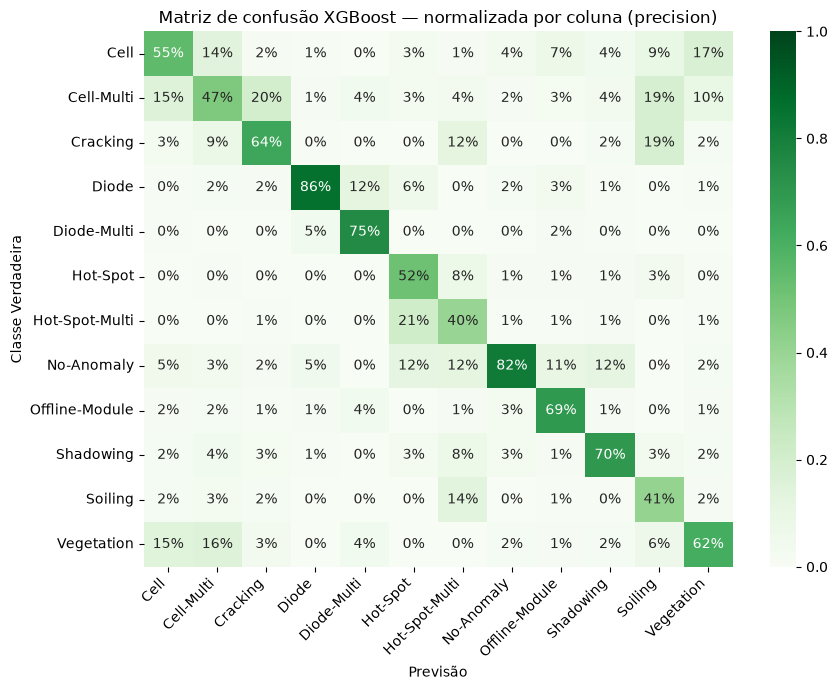

In [2]:
cm_prec = confusion_matrix(y_te, pred, labels=classes, normalize="pred")
plt.figure(figsize=(9, 7))
sns.heatmap(cm_prec, annot=True, fmt=".0%", cmap="Greens", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusão XGBoost — normalizada por coluna (precision)")
plt.ylabel("Classe Verdadeira"); plt.xlabel("Previsão")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

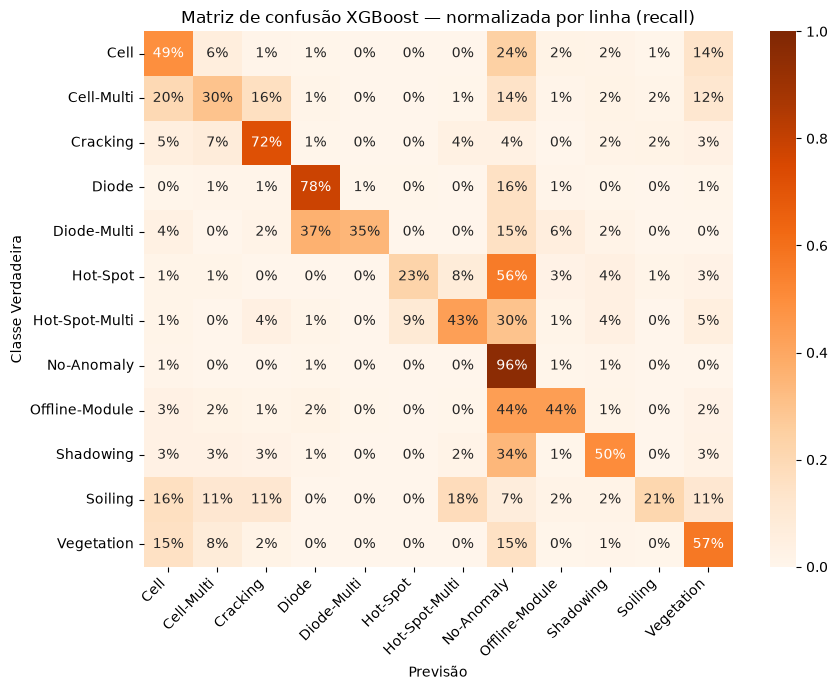

In [3]:
cm_rec = confusion_matrix(y_te, pred, labels=classes, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm_rec, annot=True, fmt=".0%", cmap="Oranges", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusão XGBoost — normalizada por linha (recall)")
plt.ylabel("Classe Verdadeira"); plt.xlabel("Previsão")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 3. Maiores confusões por classe

Para cada classe verdadeira, seu acerto próprio (recall) e as cinco classes com que mais
se confunde. Útil para decidir agrupamentos.

In [4]:
print("Classe (acerto) -> top 5 confusoes:")
for i, real in enumerate(classes):
    fora = cm_rec[i].copy()
    fora[i] = 0
    ordem = np.argsort(fora)[::-1][:5]
    tops = ", ".join(f"{classes[j]} {fora[j]*100:.0f}%" for j in ordem if fora[j] > 0)
    print(f"  {real:16s} ({cm_rec[i, i]*100:3.0f}%) -> {tops}")

Classe (acerto) -> top 5 confusoes:
  Cell             ( 49%) -> No-Anomaly 24%, Vegetation 14%, Cell-Multi 6%, Offline-Module 2%, Shadowing 2%
  Cell-Multi       ( 30%) -> Cell 20%, Cracking 16%, No-Anomaly 14%, Vegetation 12%, Shadowing 2%
  Cracking         ( 72%) -> Cell-Multi 7%, Cell 5%, No-Anomaly 4%, Hot-Spot-Multi 4%, Vegetation 3%
  Diode            ( 78%) -> No-Anomaly 16%, Offline-Module 1%, Cracking 1%, Cell-Multi 1%, Vegetation 1%
  Diode-Multi      ( 35%) -> Diode 37%, No-Anomaly 15%, Offline-Module 6%, Cell 4%, Shadowing 2%
  Hot-Spot         ( 23%) -> No-Anomaly 56%, Hot-Spot-Multi 8%, Shadowing 4%, Vegetation 3%, Offline-Module 3%
  Hot-Spot-Multi   ( 43%) -> No-Anomaly 30%, Hot-Spot 9%, Vegetation 5%, Shadowing 4%, Cracking 4%
  No-Anomaly       ( 96%) -> Shadowing 1%, Cell 1%, Diode 1%, Offline-Module 1%, Hot-Spot-Multi 0%
  Offline-Module   ( 44%) -> No-Anomaly 44%, Cell 3%, Vegetation 2%, Diode 2%, Cell-Multi 2%
  Shadowing        ( 50%) -> No-Anomaly 34%, Cell 3%

Dois padrões: anomalias sutis confundidas com `No-Anomaly`, e classes irmãs (mesmo defeito
em grau diferente) se misturando. Agrupamentos óbvios: Cell+Cell-Multi, Diode+Diode-Multi,
Hot-Spot+Hot-Spot-Multi.

## 4. Agrupamento das classes irmãs (12 → 9)

In [5]:
SUB = {"Cell-Multi": "Cell", "Diode-Multi": "Diode", "Hot-Spot-Multi": "Hot-Spot"}
y_tr_g = np.array([SUB.get(c, c) for c in y_tr])
y_te_g = np.array([SUB.get(c, c) for c in y_te])
lo = LabelEncoder().fit(y_tr_g)
xgb_g = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3, tree_method="hist",
                      random_state=42, n_jobs=-1, eval_metric="mlogloss")
xgb_g.fit(Xtr, lo.transform(y_tr_g), sample_weight=compute_sample_weight("balanced", y_tr_g))
pred_g = lo.inverse_transform(xgb_g.predict(Xte))

a12, f12 = accuracy_score(y_te, pred) * 100, f1_score(y_te, pred, average="macro") * 100
a9, f9 = accuracy_score(y_te_g, pred_g) * 100, f1_score(y_te_g, pred_g, average="macro") * 100
tab_grp = pd.DataFrame([
    {"cenario": "12 classes", "acuracia": round(a12, 1), "f1_macro": round(f12, 1)},
    {"cenario": "9 classes (agrupado)", "acuracia": round(a9, 1), "f1_macro": round(f9, 1)},
]).set_index("cenario")
print(tab_grp)
print(f"\nGanho do agrupamento: F1 macro {f9-f12:+.1f} pontos, acurácia {a9-a12:+.1f} pontos")

                      acuracia  f1_macro
cenario                                 
12 classes                74.2      53.9
9 classes (agrupado)      77.5      61.7

Ganho do agrupamento: F1 macro +7.8 pontos, acurácia +3.4 pontos


O agrupamento elimina as confusões entre irmãs e eleva o F1 macro de ~54% para ~62%.

## 5. Otimização por remoção de características

Mede-se a importância de cada feature por permutação (queda no F1 ao embaralhá-la). As de
importância nula ou negativa são removidas e o modelo é re-treinado.

In [7]:
perm = permutation_importance(xgb, Xte, le.transform(y_te), n_repeats=5,
                              random_state=42, scoring="f1_macro", n_jobs=-1)
imp = pd.DataFrame({"feature": FEAT_NAMES, "imp": perm.importances_mean}).sort_values("imp")
manter = [FEAT_NAMES.index(fn) for fn in imp[imp["imp"] > 0]["feature"]]
print(f"Features removidas (importancia <= 0): {len(FEAT_NAMES) - len(manter)} de {len(FEAT_NAMES)}")

xgb_r = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3, tree_method="hist",
                      random_state=42, n_jobs=-1, eval_metric="mlogloss")
xgb_r.fit(Xtr[:, manter], le.transform(y_tr), sample_weight=compute_sample_weight("balanced", y_tr))
pred_r = le.inverse_transform(xgb_r.predict(Xte[:, manter]))
ar, fr = accuracy_score(y_te, pred_r) * 100, f1_score(y_te, pred_r, average="macro") * 100
print(pd.DataFrame([
    {"conjunto": "completo", "n_feat": len(FEAT_NAMES), "acuracia": round(a12, 1), "f1_macro": round(f12, 1)},
    {"conjunto": "reduzido", "n_feat": len(manter), "acuracia": round(ar, 1), "f1_macro": round(fr, 1)},
]).set_index("conjunto"))
print(f"\nRemovendo {len(FEAT_NAMES) - len(manter)} features (~1/3): "
      f"F1 macro {fr-f12:+.1f}, acurácia {ar-a12:+.1f} (perda desprezível).")

Features removidas (importancia <= 0): 66 de 181
          n_feat  acuracia  f1_macro
conjunto                            
completo     181      74.2      53.9
reduzido     115      73.9      53.4

Removendo 66 features (~1/3): F1 macro -0.5, acurácia -0.3 (perda desprezível).


Cerca de um terço das características era dispensável: o modelo reduzido mantém o desempenho
com bem menos features, ficando mais leve e rápido. O gráfico abaixo mostra as características
mais e menos importantes.

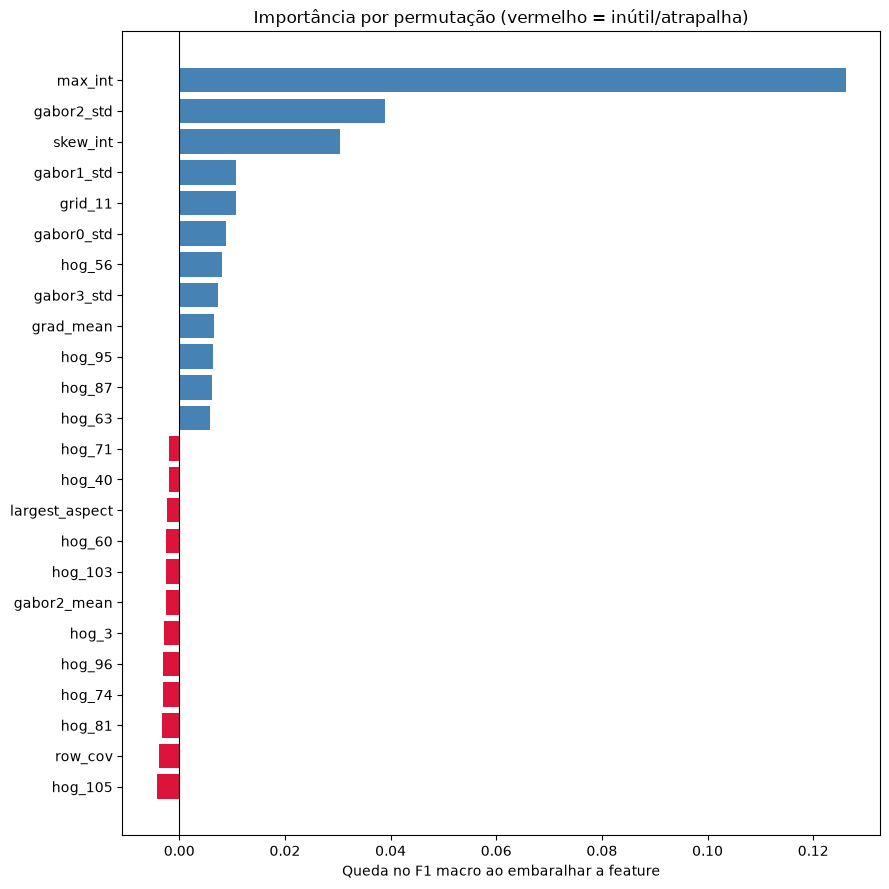

In [8]:
# Gráfico: 12 features mais e menos importantes
extremos = pd.concat([imp.head(12), imp.tail(12)])
plt.figure(figsize=(9, 9))
cores = ["crimson" if v <= 0 else "steelblue" for v in extremos["imp"]]
plt.barh(extremos["feature"], extremos["imp"], color=cores)
plt.axvline(0, color="black", lw=0.8)
plt.title("Importância por permutação (vermelho = inútil/atrapalha)")
plt.xlabel("Queda no F1 macro ao embaralhar a feature")
plt.tight_layout(); plt.show()